In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()                 # si el notebook está en la raíz del repo
# PROJECT_ROOT = Path(__file__).resolve().parent  # si fuese script .py
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
from i308_utils import imshow, show_images

CALIBRACION DE LA CAMARA.

In [6]:
# Definición del checkerboard

checkerboard = (10, 7)
square_size_mm = 24.2


In [7]:
from utils.calib import board_points

# creamos los puntos del mundo del objeto checkerboard
checkerboard_world_points_mm = board_points(checkerboard) * square_size_mm


In [8]:
import glob, os

directory = os.path.join("datasets", "stereo_budha_charuco", "calib")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"

def numeric_sort(file_name):
    return int(file_name.split("_")[-1].split(".")[0])

left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [9]:
import cv2

image_size = None
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

world_points = []
left_images = []
right_images = []
left_images_points = []
right_images_points = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)

    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # get the images sizes
    left_size = (left_image.shape[1], left_image.shape[0])
    right_size = (right_image.shape[1], right_image.shape[0])

    # checks that images sizes match
    if left_size != right_size:
        raise Exception(f"left and right images sizes differ: left {left_size} / right {right_size}")
        
    if image_size is None:
        # remembers the images size
        image_size = left_size
    else:
        if image_size != left_size:
            raise Exception(f"there are images with different sizes: {image_size} vs {left_size}")

    # finds the checkerboard in each image
    left_found, left_corners = cv2.findChessboardCorners(left_image, checkerboard)
    right_found, right_corners = cv2.findChessboardCorners(right_image, checkerboard)

    if not left_found or not right_found:
        print("warning, checkerboard was not found")
        print("  left found:", left_found)
        print("  right found:", right_found)
        continue

    # checkerboard was found in both images.

    # let's improve the found corners
    corners_left = cv2.cornerSubPix(left_image, left_corners, (7, 7), (-1,-1), criteria)
    corners_right = cv2.cornerSubPix(right_image, right_corners, (7, 7), (-1,-1), criteria)

    # acumulo las imagenes
    left_images.append(left_image)
    right_images.append(right_image)

    # acumulo los corners detectados
    left_images_points.append(left_corners)
    right_images_points.append(right_corners)

    # acumulo los puntos del mundo
    world_points.append(checkerboard_world_points_mm)



processing datasets/stereo_budha_charuco/calib/left_1.jpg datasets/stereo_budha_charuco/calib/right_1.jpg
processing datasets/stereo_budha_charuco/calib/left_2.jpg datasets/stereo_budha_charuco/calib/right_2.jpg
processing datasets/stereo_budha_charuco/calib/left_3.jpg datasets/stereo_budha_charuco/calib/right_3.jpg
processing datasets/stereo_budha_charuco/calib/left_4.jpg datasets/stereo_budha_charuco/calib/right_4.jpg
processing datasets/stereo_budha_charuco/calib/left_5.jpg datasets/stereo_budha_charuco/calib/right_5.jpg
processing datasets/stereo_budha_charuco/calib/left_6.jpg datasets/stereo_budha_charuco/calib/right_6.jpg
processing datasets/stereo_budha_charuco/calib/left_7.jpg datasets/stereo_budha_charuco/calib/right_7.jpg
processing datasets/stereo_budha_charuco/calib/left_8.jpg datasets/stereo_budha_charuco/calib/right_8.jpg
processing datasets/stereo_budha_charuco/calib/left_9.jpg datasets/stereo_budha_charuco/calib/right_9.jpg
processing datasets/stereo_budha_charuco/calib

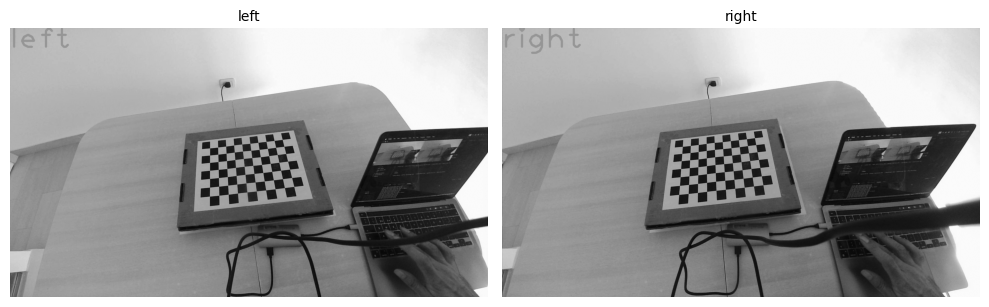

In [10]:
show_images([
    left_images[14], right_images[14]
], ['left', 'right'])

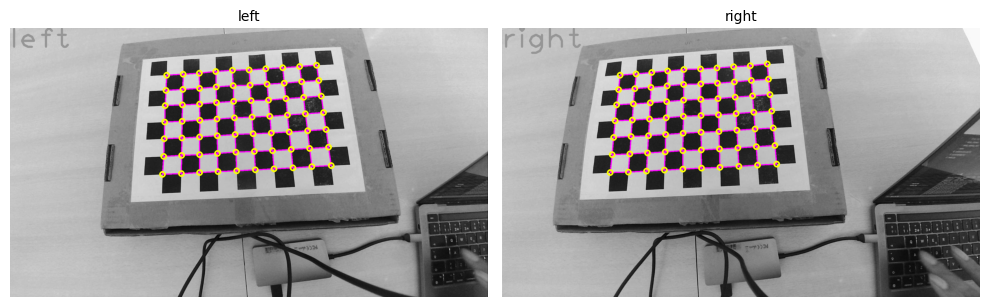

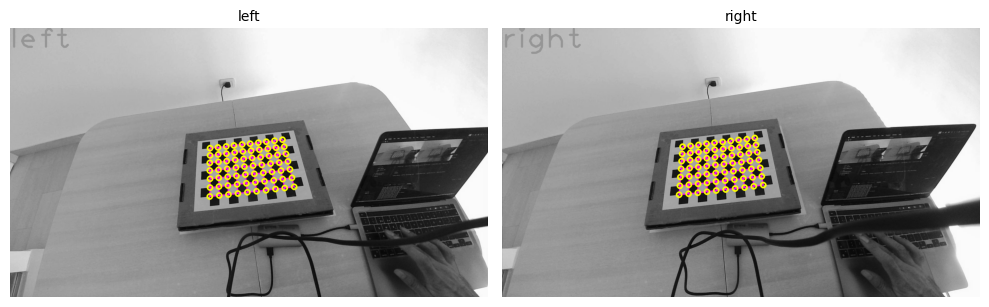

In [11]:
# grafiquemos algunos checkerboards
# y sus detecciones de corners
#  para verificar que lo que encontró está ok:

import utils.calib as calib
some_images_indices = [5, 14]

draw_settings = {
    "corner_radius": 10,
    "corner_thickness": 5,
    "line_thickness": 4
}
for i in some_images_indices:

    left_img, right_img = left_images[i], right_images[i]
    left_corners, right_corners = left_images_points[i], right_images_points[i]

    show_left = cv2.cvtColor(left_img, cv2.COLOR_GRAY2BGR)
    show_right = cv2.cvtColor(right_img, cv2.COLOR_GRAY2BGR)


    calib.draw_checkerboard(show_left, checkerboard, left_corners, True, **draw_settings)
    calib.draw_checkerboard(show_right, checkerboard, right_corners, True, **draw_settings)
    

    show_images([show_left, show_right], ["left", "right"])

In [12]:
# Calibramos Stereo

print("Calibrating Stereo")
print("num images:", len(left_images_points))

err, left_K, left_dist, right_K, right_dist, R, T, E, F = cv2.stereoCalibrate(
    world_points, 
    left_images_points, 
    right_images_points, 
    None, 
    None, 
    None, 
    None, 
    image_size, 
    flags=0
)

Calibrating Stereo
num images: 20


In [13]:
from utils.calib import np_print

to_print = [

    "# Left camera Intrinsics:",
    ("left_K", left_K),
    ("left_dist", left_dist),

    "# Right camera Intrinsics:",
    ("right_K", right_K),
    ("right_dist", right_dist),

    "# Rotation:",
    ("R", R),

    "# Translation:",
    ("T", T),
    
    "# Essential Matrix:",
    ("E", E),
    
    "# Fundamental Matrix:",
    ("F", F),
        
]

In [14]:
print("# STEREO CALIBRATION")
for line in to_print:

    if isinstance(line, str):   
        print(line)
    else:
        var_name, np_array = line
        print(f"{var_name} = {np_print(np_array)}\n")

# STEREO CALIBRATION
# Left camera Intrinsics:
left_K = np.array([
	[   600.566,	     0.000,	   950.825],
	[     0.000,	   601.170,	   540.555],
	[     0.000,	     0.000,	     1.000]
])

left_dist = np.array([
	[  0.016174,	 -0.032398,	 -0.001841,	 -0.000124,	  0.005915]
])

# Right camera Intrinsics:
right_K = np.array([
	[   600.364,	     0.000,	   951.696],
	[     0.000,	   600.969,	   527.345],
	[     0.000,	     0.000,	     1.000]
])

right_dist = np.array([
	[  0.016344,	 -0.032111,	 -0.001719,	  0.000826,	  0.005613]
])

# Rotation:
R = np.array([
	[     1.000,	     0.001,	     0.001],
	[    -0.001,	     1.000,	     0.010],
	[    -0.001,	    -0.010,	     1.000]
])

# Translation:
T = np.array([
	[-59.957285],
	[  0.206685],
	[  0.311148]
])

# Essential Matrix:
E = np.array([
	[    -0.000,	    -0.313,	     0.203],
	[     0.228,	    -0.619,	    59.954],
	[    -0.153,	   -59.954,	    -0.619]
])

# Fundamental Matrix:
F = np.array([
	[     0.000,	     0.000,	    -0.047],
	[    -0.0

In [15]:
# serializamos los resultados en un pickle
import pickle

calibration_results = {
    'left_K': left_K,
    'left_dist': left_dist,
    'right_K': right_K,
    'right_dist': right_dist,
    'R': R,
    'T': T,
    'E': E,
    'F': F,
    'image_size': image_size,
}

calibration_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
with open(calibration_file, "wb") as f:
    f.write(pickle.dumps(calibration_results))
        


RECTIFICACION

In [16]:
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist, right_K, right_dist, image_size, R, T, alpha=0
)

In [17]:
# calculemos los mapas de des-distorsión-rectificación:

left_map_x, left_map_y = cv2.initUndistortRectifyMap(left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1)

In [18]:
# Qué pinta tienen estos mapas?
# chequeemos el shape, debería coincidir con image_size
left_map_x.shape

(1080, 1920)

In [19]:
# Qué valores contiene?
# en este caso son floats, por lo que se necesitará alguna forma de interpolación
left_map_x[0:3, 0:3]

array([[71.92991 , 72.81698 , 73.70274 ],
       [71.93488 , 72.82117 , 73.706154],
       [71.93944 , 72.82494 , 73.70915 ]], dtype=float32)

In [20]:
# tomemos un par estéreo
image_index = 5

left_image = left_images[image_index]
right_image = right_images[image_index]

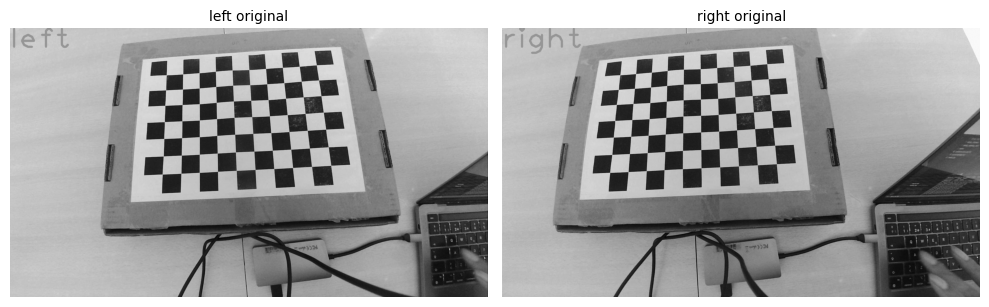

In [21]:
# muestro las imagenes:
show_images([
    left_image, right_image
], [
    "left original", "right original"
])


In [22]:
# aplicamos des-distorsion + rectificación, con los mapas que calculamos ateriormente
left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

In [23]:
import numpy as np

# Ejemplo, para saber qué valor poner en la posición (i,j) de la imagen destino,
# a cuál píxel en la imagen original tendríamos que ir buscar?
x_dest, y_dest = 321, 123

x_ori = left_map_x[y_dest, x_dest]
y_ori = left_map_y[y_dest, x_dest]

x_ori = int(np.round(x_ori))
y_ori = int(np.round(y_ori))

print(f"using nearest neighbor interpolation, I_dest[{y_dest}, {x_dest}] = I_ori[{y_ori}, {x_ori}]")

print(left_image[y_ori, x_ori])
print(left_image_rectified[y_dest, x_dest])


using nearest neighbor interpolation, I_dest[123, 321] = I_ori[146, 330]
194
194


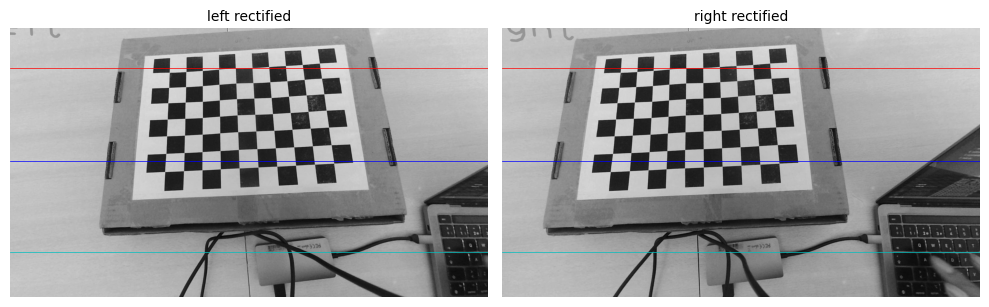

In [24]:
# muestro las imagenes stereo-rectificadas
# observar el vertice de la caja, de la notebook, y del cuaderno. 
# coinciden perfectamente en y.
from matplotlib import pyplot as plt 

fig, axes = show_images([
    left_image_rectified, right_image_rectified
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

In [25]:
# Guardemos los resultados de rectificación para usar posteriormente:

stereo_maps = {

    # undistorting maps
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,

    # add also rectifying info:
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,

}

stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")
with open(stereo_maps_file, "wb") as f:
    f.write(pickle.dumps(stereo_maps))
        

In [26]:
import os

left_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "left_10.jpg")
right_image_file = os.path.join("datasets","stereo_budha_charuco", "captures", "right_10.jpg")

left_image = cv2.imread(left_image_file, 0)
right_image = cv2.imread(right_image_file, 0)

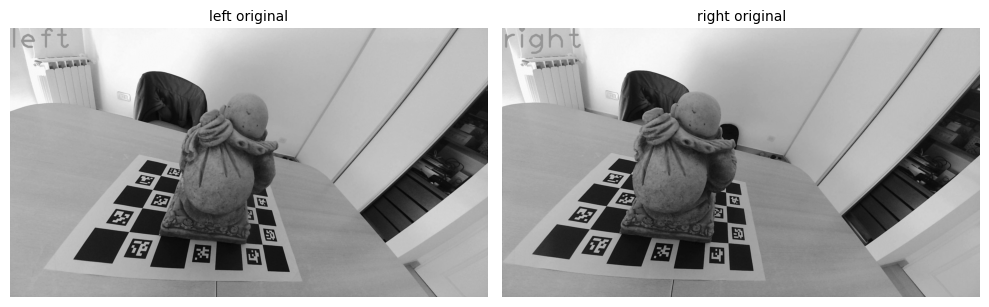

In [27]:

fig, axes = show_images([
    left_image, right_image
], [
    "left original", "right original"
], show=False)



In [28]:

import pickle


stereo_calib_file = os.path.join("datasets","stereo_budha_charuco", "stereo_calibration.pkl")
stereo_maps_file = os.path.join("datasets","stereo_budha_charuco", "stereo_rectification_maps.pkl")

print("reading stereo calibration results...")
with open(stereo_calib_file, "rb") as f:
    calibration = pickle.loads(f.read())
    
print("reading stereo rectification maps...")
with open(stereo_maps_file, "rb") as f:
    maps = pickle.loads(f.read())

reading stereo calibration results...
reading stereo rectification maps...


In [29]:
left_map_x, left_map_y = maps['left_map_x'], maps['left_map_y']
right_map_x, right_map_y = maps['right_map_x'], maps['right_map_y']

In [30]:

directory = os.path.join("datasets", "stereo_budha_charuco", "captures")
left_files_pattern = "*left*.jpg"
right_files_pattern = "*right*.jpg"


left_file_names = sorted(
    glob.glob(
        os.path.join(directory, left_files_pattern)
    ),
    key=numeric_sort
)

right_file_names = sorted(
    glob.glob(
        os.path.join(directory, right_files_pattern)
    ),
    key=numeric_sort
)

num_left = len(left_file_names)
num_right = len(right_file_names)

if  num_left != num_right:
    raise Exception(f"the number of files (left {num_left} / right{num_right}) doesn't match")

In [31]:


left_images_rectified = []
right_images_rectified = []

for left_file_name, right_file_name in zip(
    left_file_names, right_file_names
):

    print("processing", left_file_name, right_file_name)


    # read left and right images
    left_image = cv2.imread(left_file_name, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_file_name, cv2.IMREAD_GRAYSCALE)

    # apply rectification
    left_image_rectified = cv2.remap(left_image, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_image_rectified = cv2.remap(right_image, right_map_x, right_map_y, cv2.INTER_LINEAR)

    left_images_rectified.append(left_image_rectified)
    right_images_rectified.append(right_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","left", left_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, left_image_rectified)


    output_file = os.path.join("datasets", "stereo_budha_charuco","rectified","right", right_file_name)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    cv2.imwrite(output_file, right_image_rectified)

    
    

processing datasets/stereo_budha_charuco/captures/left_0.jpg datasets/stereo_budha_charuco/captures/right_0.jpg
processing datasets/stereo_budha_charuco/captures/left_1.jpg datasets/stereo_budha_charuco/captures/right_1.jpg
processing datasets/stereo_budha_charuco/captures/left_2.jpg datasets/stereo_budha_charuco/captures/right_2.jpg
processing datasets/stereo_budha_charuco/captures/left_3.jpg datasets/stereo_budha_charuco/captures/right_3.jpg
processing datasets/stereo_budha_charuco/captures/left_4.jpg datasets/stereo_budha_charuco/captures/right_4.jpg
processing datasets/stereo_budha_charuco/captures/left_5.jpg datasets/stereo_budha_charuco/captures/right_5.jpg
processing datasets/stereo_budha_charuco/captures/left_6.jpg datasets/stereo_budha_charuco/captures/right_6.jpg
processing datasets/stereo_budha_charuco/captures/left_7.jpg datasets/stereo_budha_charuco/captures/right_7.jpg
processing datasets/stereo_budha_charuco/captures/left_8.jpg datasets/stereo_budha_charuco/captures/righ

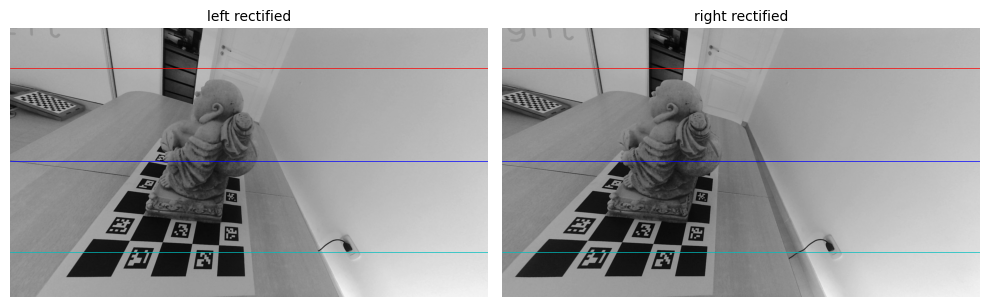

In [32]:
# tomemos un par estéreo
image_index = 6

# show images
fig, axes = show_images([
    left_images_rectified[image_index], right_images_rectified[image_index]
], [
    "left rectified", "right rectified"
], show=False)

for y, c in zip([160, 533, 900], ['r', 'b', 'c']):
    axes[0].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
    axes[1].axhline(y=y, color=c, linestyle='-', linewidth=0.5)
plt.show()

DISPARIDAD


In [33]:
w, h = left_image.shape[1], left_image.shape[0]

fx = left_K[0][0]
fy = left_K[1][1]
cx0 = left_K[0][2]
cy0 = left_K[1][2]

baseline = np.linalg.norm(T)

In [35]:
# Cre Stereo

import cv2
import json
import numpy as np
from pathlib import Path

from utils.disparity.method_cre_stereo import CREStereo
from utils.disparity.methods import Calibration, InputPair, Config


calibration = Calibration(**{
    "width": w,
    "height": h,
    "baseline_meters": baseline / 1000,
    "fx": fx,
    "fy": fy,
    "cx0": cx0,
    "cx1": cx0,
    "cy": cy0,
    "depth_range": [0.05, 20.0],
    "left_image_rect_normalized": [0, 0, 1, 1]
})

In [36]:
import os

models_path = "models"
if not os.path.exists(models_path):
    os.makedirs(models_path)

In [37]:
#models_path = Path.home() / ".cache" / "stereodemo" / "models"
models_path = Path(models_path)
pair = InputPair(left_image_rectified, right_image_rectified, calibration)
# pair = InputPair(left_image, right_image, calibration)
config = Config(models_path=models_path)

# params = {
#    "Shape": "1280x720",
#    "Mode": "combined",
#    "Iterations": 20
#}
method = CREStereo(config)

#method.parameters["Shape"].set_value("640x480")
method.parameters["Shape"].set_value("1280x720")
# method.parameters["Iterations"].set_value("10")

#method.parameters.update(params)
# method = StereoBM(config)
# method = StereoSGBM(config)
# method = StereoBM(config)
disparity = method.compute_disparity(pair)

models/crestereo_combined_iter5_720x1280.onnx


/Users/damiandistefano/Documents/UDESA/3 año/2 semestre/Vision artificial/TPs/Untitled/.venv/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [38]:
disparity.disparity_pixels.shape

(1080, 1920)

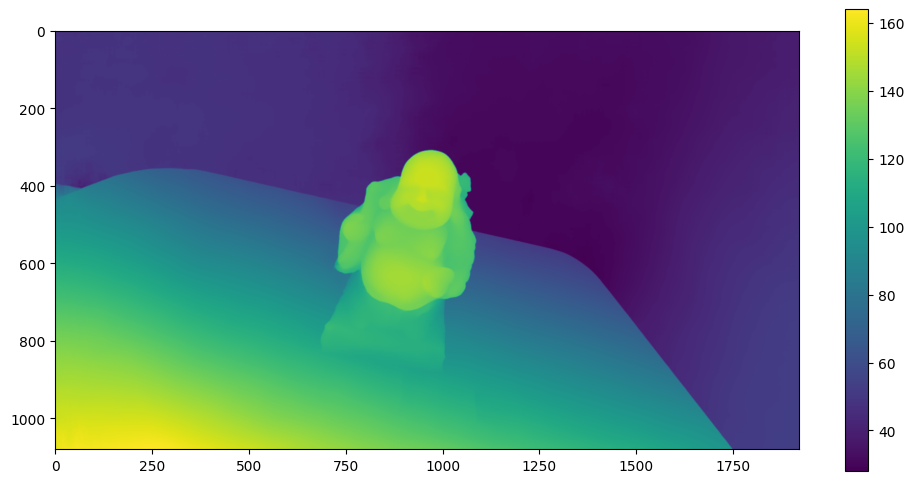

In [39]:
plt.figure(figsize=(12, 6))
plt.imshow(disparity.disparity_pixels)
plt.colorbar()
plt.show()

PROFUNDIDAD

In [40]:
def compute_depth(disparity_map, f, B, default=1000.0):

    # Crea una copia del mapa de disparidad
    disparity_map = disparity_map.copy()

    # Evita divisiones por cero o disparidades negativas (les asignamos el valor default)
    mask_invalid = (disparity_map <= 0)

    # Calcula la profundidad con la fórmula Z = f * B / disparidad
    depth_map = np.zeros_like(disparity_map, dtype=np.float32)
    depth_map[~mask_invalid] = (f * B) / disparity_map[~mask_invalid]

    # Asigna valor fijo a los puntos donde la disparidad es inválida
    depth_map[mask_invalid] = default

    return depth_map

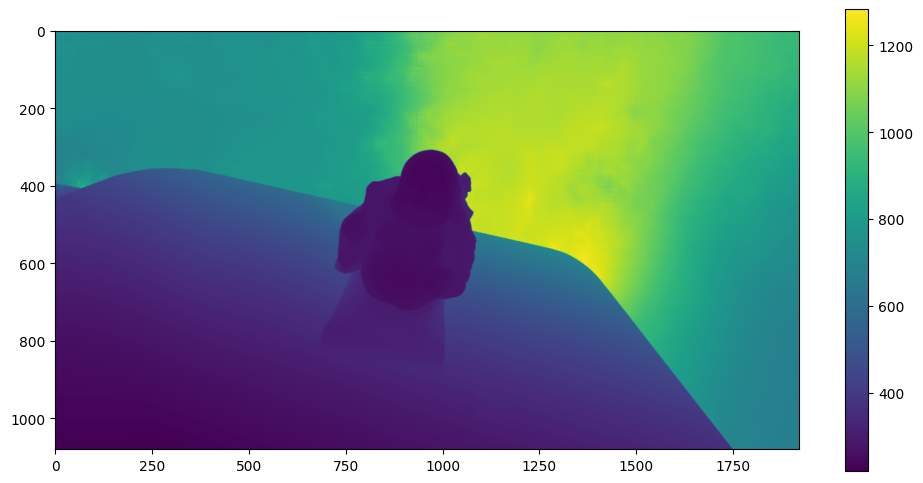

In [41]:
# disparity = np.load("disparity.npz")["arr_0"]
disparity_map = disparity.disparity_pixels
f = left_K[0][0]
B = baseline = np.linalg.norm(T)

depth = compute_depth(disparity_map, f, B)
plt.figure(figsize=(12, 6))
plt.imshow(depth)
plt.colorbar()
plt.show()

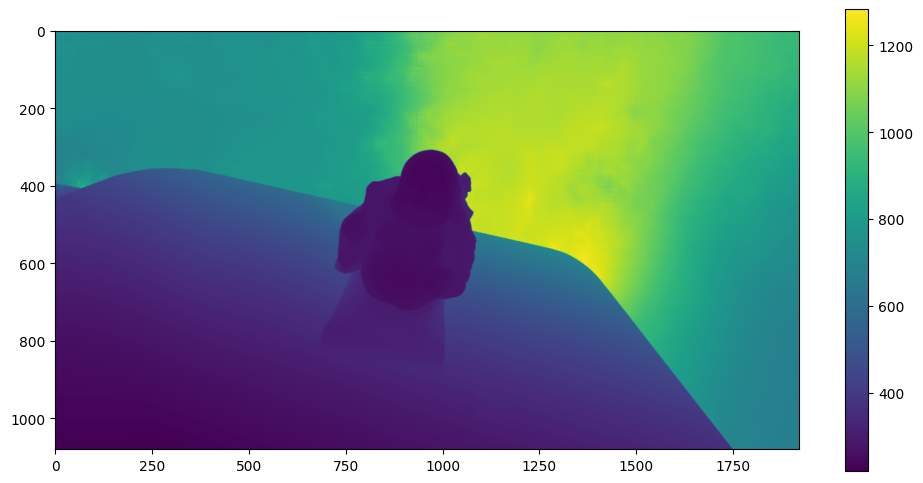

In [45]:
depth2 = depth.copy()
depth2[depth2 > 10000] = 10000

plt.figure(figsize=(12, 6))
plt.imshow(depth2)
plt.colorbar()
plt.show()

Para cada par estéreo en el dataset:

rectificamos cada imagen del par

Checkerboard en 3d

detectamos el tablero en cada imagen, y calculamos la disparidad de los corners
con la disparidad obtenemos la posicion en 3d de los corners.
podemos encontrar versores en el checkerboard,
con esos versores podemos encontrar una caja en 3d que englobe la estatua (que usaremos para filtrar solamente los puntos 3d que nos interesan)
Disparidad de la escena:

Calculamos los mapas de disparidad de la escena, usando matching estéreo (con el método que prefieran, veremos más adelante detalles)
Profundidad, con los mapas de disparidad obtenemos la nube de puntos de la escena

Con la profundidad y los parámetros de la rectificación, obtenemos la nube de puntos 3d de la escena

Exportamos la PCD a un archivo, puede ser el estandard .PLY, que se puede trabajar con Meshlab

In [97]:
from code_examples.charuco_example import aruco

use_dict = cv2.aruco.DICT_6X6_250
squares_x=5
squares_y=7
square_length=52.6
marker_length=31.3


board = aruco.create_charuco_board(
    squares_x,
    squares_y,
    square_length,
    marker_length,
    use_dict
)


In [98]:
def estimate_pose_cv(img, board, detection, calibration):

    K, dist_coeffs = calibration
    corners = detection['corners']
    ids = detection['ids']

    # para encontrar la pose, OpenCV recomienda usar interpolateCornersCharuco
    # para estimar donde están los corners del tablero
    # luego busca con precisión de sub-píxel los corners y devuelve los resultados mejorados
    interpolation = cv2.aruco.interpolateCornersCharuco(
        markerCorners=corners,
        markerIds=ids,
        image=img,
        board=board
    )
    # el resultado es la cantidad de corners que pudo interpolar
    # las posiciones de los corners interpolados y los ids correspondientes.
    num, ch_corners, ch_ids = interpolation
    if num < 4:
        print ("no se pudo interpolar la pose.")
        return False, None, None
    # la librería devuelve la pose usando la función estimatePoseCharucoBoard
    pose = cv2.aruco.estimatePoseCharucoBoard(
        ch_corners,
        ch_ids,
        board,
        K,
        dist_coeffs,
        np.empty(1),
        np.empty(1)
    )
    ok, rv, tv = pose

    return pose

In [100]:
from pathlib import Path
import json, cv2
import numpy as np

# Carpetas
LEFT_DIR = Path("datasets/stereo_budha_charuco/rectified/left")
OUT_DIR  = Path("datasets/stereo_budha_charuco/out/per_pair"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# Intrínsecos para imágenes RECTIFICADAS:
K = P1[:3, :3]
dist_coeffs = None
calibration = (K, dist_coeffs)   # si tu helper lo espera así

# Utilidad: guardar pose a JSON
def save_pose_json(path, rvec, tvec):
    R,_ = cv2.Rodrigues(rvec)
    payload = {
        "rvec": rvec.reshape(-1).tolist(),
        "tvec": tvec.reshape(-1).tolist(),
        "R":    R.tolist()
    }
    path.write_text(json.dumps(payload, indent=2))

# Iterar izquierdas (ajustá extensiones si hace falta)
left_paths = sorted(list(LEFT_DIR.glob("*.jpg")) + list(LEFT_DIR.glob("*.png")) + list(LEFT_DIR.glob("*.JPG")))
ok_count, det_fail, pose_fail = 0, 0, 0

for Lp in left_paths:
    img = cv2.imread(str(Lp))
    if img is None:
        print(f"[WARN] No pude leer {Lp}"); 
        continue

    # 1) Detección (tu helper del módulo de la materia)
    detection = aruco.detect_charuco_markers(img, board)
    if not detection or detection.get("ids") is None or len(detection["ids"]) == 0:
        det_fail += 1
        print(f"[WARN] Sin detección en {Lp.name}")
        continue

    # 2) Pose (tu helper con homografía)
    ok, rvec, tvec = aruco.estimate_camera_pose_with_homography(img, board, detection, calibration)
    if not ok:
        pose_fail += 1
        print(f"[WARN] Sin pose en {Lp.name}")
        continue

    # 3) Evidencia: dibujar detección y ejes (ejes más cortos para que entren)
    vis = aruco.draw_aruco_results(img.copy(), detection, size=3)
    cv2.drawFrameAxes(vis, K, dist_coeffs, rvec, tvec, square_length * 1.5)

    # 4) Guardar JSON + PNG con el mismo índice que la imagen
    idx = Lp.stem.split("_")[-1] if "_" in Lp.stem else Lp.stem
    save_pose_json(OUT_DIR / f"pose_{idx}.json", rvec, tvec)
    cv2.imwrite(str(OUT_DIR / f"pose_{idx}.png"), vis)
    ok_count += 1

print(f"[OK] Poses guardadas: {ok_count}  | sin detección: {det_fail}  | sin pose: {pose_fail}")





[OK] Poses guardadas: 21  | sin detección: 0  | sin pose: 0


[ WARN:0@107159.826] global solvepnp.cpp:123 drawFrameAxes Some of projected axes endpoints are out of frame. The drawn axes may be not reliable.
[ WARN:0@107159.880] global solvepnp.cpp:123 drawFrameAxes Some of projected axes endpoints are out of frame. The drawn axes may be not reliable.
[ WARN:0@107159.946] global solvepnp.cpp:123 drawFrameAxes Some of projected axes endpoints are out of frame. The drawn axes may be not reliable.


Versores del checkerboard y caja 3D para filtrar la estatua

In [ ]:
import sys, cv2, open3d as o3d, numpy as np

In [ ]:
import json
import numpy as np
import cv2 as cv
import open3d as o3d
from pathlib import Path

def load_pose_Tbc(pose_json_path):
    """Lee rvec/tvec (tablero->cámara) y devuelve T_bc (cámara->tablero)."""
    info = json.loads(Path(pose_json_path).read_text())
    rvec = np.array(info["rvec"], dtype=np.float64).reshape(3,1)
    tvec = np.array(info["tvec"], dtype=np.float64).reshape(3,1)
    R_cb, _ = cv.Rodrigues(rvec)
    T_cb = np.eye(4); T_cb[:3,:3] = R_cb; T_cb[:3,3] = tvec.ravel()
    T_bc = np.linalg.inv(T_cb)
    return T_bc

def numpy_to_o3d(xyz, rgb=None):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz.astype(np.float64))
    if rgb is not None:
        pcd.colors = o3d.utility.Vector3dVector((rgb.astype(np.float64)/255.0))
    return pcd

def process_pair_to_ply(idx_par, Lr, disp, Q, pose_json_path, board,
                        out_dir, margin_xy=0.03, z_min=0.10, z_max=0.80):
    """
    idx_par: string, ej '0007'
    Lr: imagen izquierda rectificada (H,W,3) BGR
    disp: disparidad (H,W) float32
    Q: matriz 4x4 de reproyección
    pose_json_path: ruta a pose_{idx}.json
    board: objeto tablero con chessboardCorners en la MISMA unidad que querés usar
    out_dir: carpeta de salida (Path)
    margin_xy, z_min, z_max: caja en marco tablero (metros si tu board está en m)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1) 3D en cámara (izquierda rectificada)
    pts3d_c = cv.reprojectImageTo3D(disp, Q)     # (H,W,3)
    m = disp > 0
    Xc  = pts3d_c[m]                             # (N,3)
    RGB = Lr[m][:, ::-1]                         # BGR->RGB

    # 2) Cámara -> Tablero
    T_bc = load_pose_Tbc(pose_json_path)
    pcd = numpy_to_o3d(Xc, RGB)
    pcd.transform(T_bc)                          # ahora en marco TABLERO

    # 3) Caja (OBB) alineada al tablero
    corners = board.chessboardCorners            # (M,3), z=0 en tablero
    xymin = corners[:, :2].min(axis=0); xymax = corners[:, :2].max(axis=0)
    board_w = float(xymax[0] - xymin[0])
    board_h = float(xymax[1] - xymin[1])

    center = np.array([(xymin[0]+xymax[0])/2, (xymin[1]+xymax[1])/2, (z_min+z_max)/2], float)
    extent = np.array([board_w + 2*margin_xy, board_h + 2*margin_xy, (z_max - z_min)], float)
    R_box = np.eye(3)                            # ya estamos en marco tablero
    box = o3d.geometry.OrientedBoundingBox(center, R_box, extent)

    # 4) Recorte + limpieza
    idx = box.get_point_indices_within_bounding_box(pcd.points)
    pcd = pcd.select_by_index(idx)
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    # opcional: pcd = pcd.voxel_down_sample(voxel_size=0.005)  # 5 mm

    # 5) Guardar
    ply_path = out_dir / f"cloud_{idx_par}_world.ply"
    o3d.io.write_point_cloud(str(ply_path), pcd, write_ascii=False)
    return ply_path


ModuleNotFoundError: No module named 'open3d'